# Workbook 2 Preprocessing & Feature Engineering

The raw data is transformed into a supervised ML dataset.

### Steps
1. Aggregate monthly bankruptcies → quarterly
2. Merge with new enterprise registrations into a panel
3. Compute the **Sector Vitality Score** (the target variable)
4. Generate **lag and rolling features** for time-series forecasting
5. Perform a **time-based train/test split**

### Panel
DEMO14 is published annually. Bankruptcies (KONK4) are published monthly. Both are aligned to a quarterly panel, annual enterprise births are forward-filled across quarters, while monthly bankruptcies are summed within each quarter.


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load raw artifacts
df_bankrupt = pd.read_csv('../artifacts/raw/bankruptcies_latest.csv', parse_dates=['period'])
df_new      = pd.read_csv('../artifacts/raw/new_enterprises_latest.csv', parse_dates=['period'])

print(f"Bankruptcies: {df_bankrupt.shape}, New enterprises: {df_new.shape}")


Bankruptcies: (2040, 4), New enterprises: (50, 3)


## 2.1 Aggregate bankruptcies to quarterly
Bankruptcies are published monthly (KONK4). Each is summed within each quarter
so the frequency matches the quarterly panel frequency.


In [2]:
from src.preprocessing import bankruptcies_to_quarterly

df_bankrupt_q = bankruptcies_to_quarterly(df_bankrupt)
print(f"Quarterly bankruptcies: {df_bankrupt_q.shape}")
print(df_bankrupt_q.head(8))


Quarterly bankruptcies: (680, 3)
   sector     period  bankruptcies
0       1 2009-01-01            14
1       1 2009-04-01            13
2       1 2009-07-01            11
3       1 2009-10-01            13
4       1 2010-01-01            11
5       1 2010-04-01            11
6       1 2010-07-01            14
7       1 2010-10-01            16


## 2.2 Build the panel
Bankruptcies and new enterprises are outer-joined on (sector, period). Missing values are filled with 0 — if a sector had no bankruptcies in a given quarter, the count is truly 0.

The panel is filtered to 2019 onwards — the earliest year where both KONK4 and DEMO14 have complete overlapping coverage. Pre-2019 rows have zero enterprise births which would distort the vitality score.


In [3]:
from src.preprocessing import build_panel

panel = build_panel(
    df_new=df_new,
    df_bankrupt=df_bankrupt_q,
    df_employment=None,
)

print(f"Panel shape: {panel.shape}")
print(f"Sectors: {panel['sector'].nunique()}")
print(f"Quarters: {panel['period'].nunique()} ({panel['period'].min().date()} → {panel['period'].max().date()})")
panel.head(12)


2026-04-16 17:20:36,620 [INFO] Panel built: 10 sectors × 68 quarters = 680 rows


Panel shape: (680, 4)
Sectors: 10
Quarters: 68 (2009-01-01 → 2025-10-01)


,sector,period,new_enterprises,bankruptcies
0,1,2009-01-01,0.0,14
1,1,2009-04-01,0.0,13
2,1,2009-07-01,0.0,11
3,1,2009-10-01,0.0,13
4,1,2010-01-01,0.0,11
5,1,2010-04-01,0.0,11
6,1,2010-07-01,0.0,14
7,1,2010-10-01,0.0,16
8,1,2011-01-01,0.0,19
9,1,2011-04-01,0.0,20


In [4]:
# Filter panel to 2019 onwards — the period where both data sources
# (KONK4 bankruptcies and DEMO14 enterprise births) have complete coverage.
# Pre-2019 rows have new_enterprises=0 (no DEMO14 data) which creates
# a false spike in the vitality score when 2019 data first appears.
panel = panel[(panel['period'] >= '2019-01-01') & (panel['period'] < '2024-01-01')].reset_index(drop=True)

print(f"Panel filtered to: {panel['period'].min().date()} → {panel['period'].max().date()}")
print(f"Sectors: {panel['sector'].nunique()}, Quarters: {panel['period'].nunique()}")

Panel filtered to: 2019-01-01 → 2023-10-01
Sectors: 10, Quarters: 20


## 2.3 Compute the Sector Vitality Score

The **Sector Vitality Score (SVS)** is the synthetic target variable.

**Formula:**
$$\text{SVS}(s,t) = \frac{\text{new\_enterprises}(s,t) - \text{bankruptcies}(s,t)}{\text{active\_estimate}(s,t)}$$

Where `active_estimate` is an evolving estimate of total active enterprises
(initialised at 100 and updated by net births/deaths each quarter).

Then **min-max normalise per sector** to get a score in [0, 1],
making sectors of different sizes comparable.

> A score near 1 = strong growth  
> A score near 0 = high stress / contraction


In [5]:
from src.preprocessing import compute_vitality_score, quality_report

panel = compute_vitality_score(panel)

# Quality report
qr = quality_report(panel)
print("Quality Report:")
for k, v in qr.items():
    if not isinstance(v, dict):
        print(f"  {k}: {v}")


2026-04-16 17:20:36,647 [INFO] Vitality score computed. Mean=0.452, Std=0.327


Quality Report:
  n_rows: 200
  n_sectors: 10
  n_quarters: 20
  period_min: 2019-01-01 00:00:00
  period_max: 2023-10-01 00:00:00
  vitality_mean: 0.4519
  vitality_std: 0.3273
  zero_bankruptcies_pct: 0.0


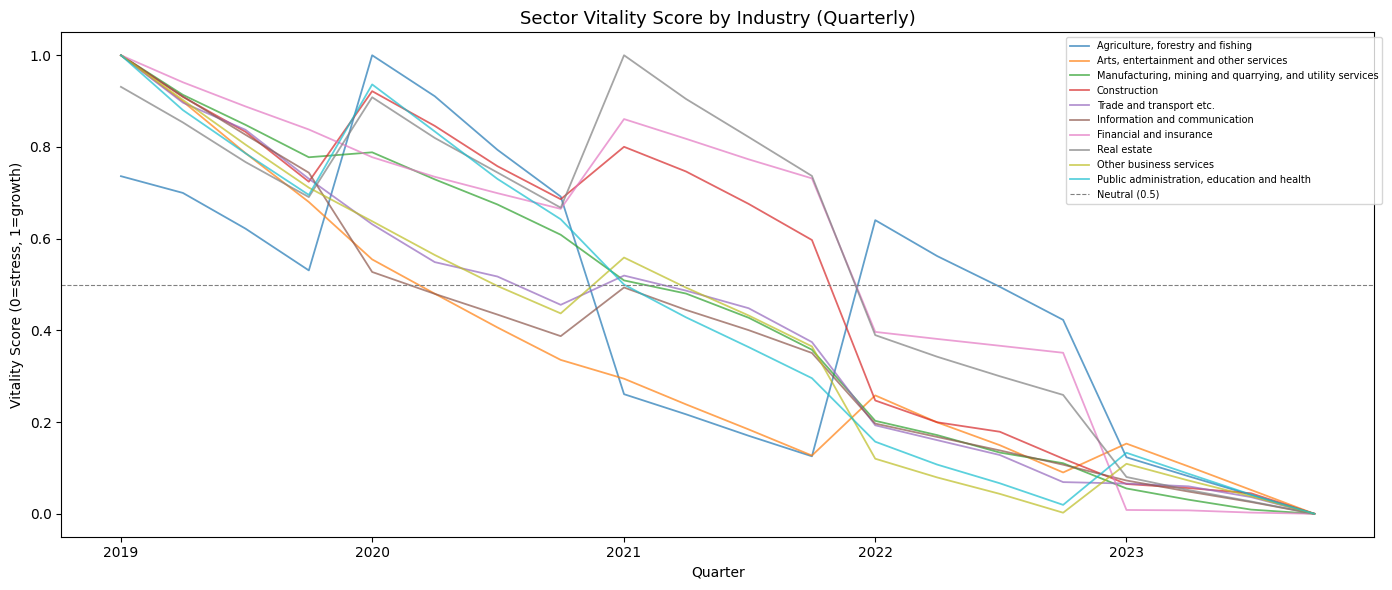

In [6]:
from src.dst_client import DSTClient

# Pull exact sector names from DST API (same as notebook 1)
client = DSTClient(language='en')
info = client.get_table_info('DEMO14')
branch_var = next(v for v in info['variables'] if v['id'] == 'BRANCHEDB0710')
sector_names = {
    v['id']: v['text'].split(' ', 1)[1] if ' ' in v['text'] else v['text']
    for v in branch_var['values']
    if v['id'] not in ('TOT', '11')
}

fig, ax = plt.subplots(figsize=(14, 6))

for sector, grp in panel.groupby('sector'):
    grp = grp.sort_values('period')
    label = sector_names.get(str(sector), str(sector))
    ax.plot(grp['period'], grp['vitality_score'], alpha=0.7, linewidth=1.3, label=label)

ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Neutral (0.5)')
ax.set_title('Sector Vitality Score by Industry (Quarterly)', fontsize=13)
ax.set_xlabel('Quarter')
ax.set_ylabel('Vitality Score (0=stress, 1=growth)')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=7)
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_vitality_scores.png', dpi=120)
plt.show()

## 2.4 Feature Engineering

The time series is converted into a supervised ML table using the following features:

| Feature type | Description |
|---|---|
| **Lag features** | Vitality score at t-1, t-2, t-3, t-4 |
| **Rolling mean** | 4-quarter and 8-quarter rolling average |
| **Rolling std** | Volatility over last 4 / 8 quarters |
| **Momentum** | First difference (change vs previous quarter) |
| **Rates** | Lagged bankruptcy rate, birth rate, net growth rate |
| **Seasonality** | Quarter-of-year (Q1/Q2/Q3/Q4) |
| **Sector dummies** | One-hot encoded sector identifier |

The **target** is vitality_score at **t+1** (one quarter ahead).


In [7]:
from src.features import build_features, get_feature_columns

df_features = build_features(
    panel,
    lag_periods=[1, 2, 3, 4],
    rolling_windows=[4, 8],
    target_col='vitality_score',
)

feature_cols = get_feature_columns(df_features)
print(f"Total features: {len(feature_cols)}")
print("\nFeature list:")
for i, f in enumerate(feature_cols):
    print(f"  {i+1:2d}. {f}")


2026-04-16 17:20:37,287 [INFO] Features built: 180 rows (20 dropped for NaN lags/target)


Total features: 33

Feature list:
   1. vitality_score_lag1
   2. bankruptcy_rate_lag1
   3. birth_rate_lag1
   4. net_growth_rate_lag1
   5. vitality_score_lag2
   6. bankruptcy_rate_lag2
   7. birth_rate_lag2
   8. net_growth_rate_lag2
   9. vitality_score_lag3
  10. bankruptcy_rate_lag3
  11. birth_rate_lag3
  12. net_growth_rate_lag3
  13. vitality_score_lag4
  14. bankruptcy_rate_lag4
  15. birth_rate_lag4
  16. net_growth_rate_lag4
  17. vitality_score_roll4_mean
  18. vitality_score_roll4_std
  19. vitality_score_roll8_mean
  20. vitality_score_roll8_std
  21. vitality_score_momentum
  22. quarter_of_year
  23. year
  24. sector_1
  25. sector_10
  26. sector_2
  27. sector_3
  28. sector_4
  29. sector_5
  30. sector_6
  31. sector_7
  32. sector_8
  33. sector_9


In [8]:
# Check a sample row
print("Sample feature row:")
print(df_features[feature_cols].iloc[10].to_string())
print(f"\nTarget: {df_features['target'].iloc[10]:.4f}")


Sample feature row:
vitality_score_lag1          0.170184
bankruptcy_rate_lag1         0.000281
birth_rate_lag1              0.034274
net_growth_rate_lag1         0.033993
vitality_score_lag2          0.217027
bankruptcy_rate_lag2         0.000339
birth_rate_lag2              0.035478
net_growth_rate_lag2         0.035139
vitality_score_lag3          0.260829
bankruptcy_rate_lag3         0.000552
birth_rate_lag3              0.036763
net_growth_rate_lag3         0.036211
vitality_score_lag4          0.691844
bankruptcy_rate_lag4         0.000867
birth_rate_lag4              0.047623
net_growth_rate_lag4         0.046756
vitality_score_roll4_mean    0.334971
vitality_score_roll4_std     0.240777
vitality_score_roll8_mean    0.571891
vitality_score_roll8_std      0.32676
vitality_score_momentum     -0.046843
quarter_of_year                     4
year                             2021
sector_1                         True
sector_10                       False
sector_2                      

## 2.5 Correlation analysis
Before modelling, a check is done which features correlate most with the target.
High correlation with lag-1 suggests the naive baseline (persistence) will be hard to beat.


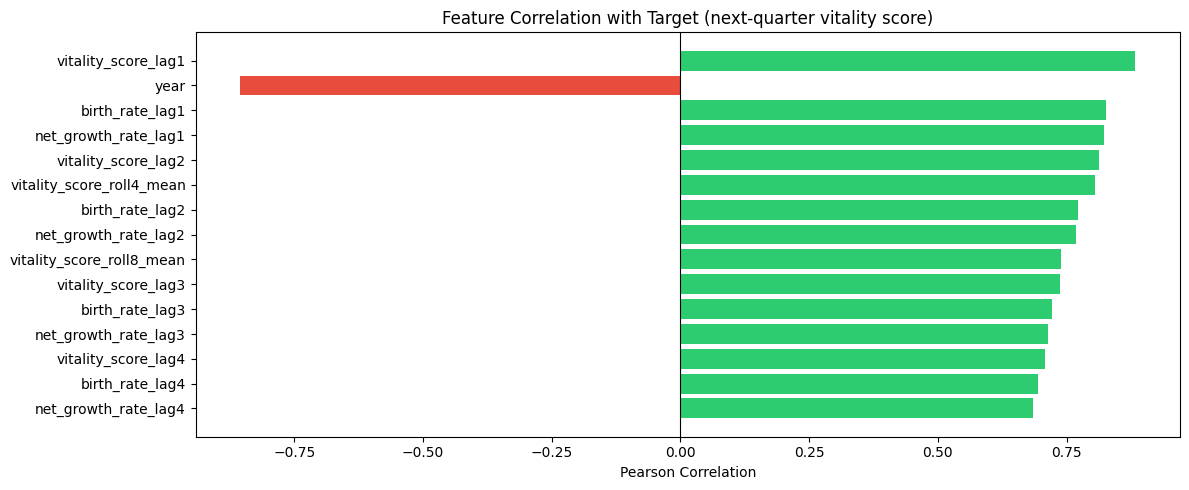

In [9]:
import seaborn as sns
from src.dst_client import DSTClient

# Pull sector names from DST API
client = DSTClient(language='en')
info = client.get_table_info('DEMO14')
branch_var = next(v for v in info['variables'] if v['id'] == 'BRANCHEDB0710')
sector_names = {
    f"sector_{v['id']}": v['text'].split(' ', 1)[1] if ' ' in v['text'] else v['text']
    for v in branch_var['values']
    if v['id'] not in ('TOT', '11')
}

# Correlation of features with target
corr = df_features[feature_cols + ['target']].corr()['target'].drop('target')
top_corr = corr.abs().sort_values(ascending=False).head(15)

# Rename index: replace sector codes with readable names
renamed_index = [sector_names.get(idx, idx) for idx in top_corr.index]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr[top_corr.index]]
ax.barh(renamed_index[::-1], corr[top_corr.index][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (next-quarter vitality score)', fontsize=12)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_feature_correlation.png', dpi=120)
plt.show()

## 2.6 Time-based train/test split

Random splitting would cause data leakage — the model could train on data from 2023 while testing on 2022, effectively predicting the past from the future. The last 8 quarters (~2 years) are held out as the test set.


2026-04-16 17:20:37,852 [INFO] Time split: train=140 rows (2019-04 → 2022-07), test=40 rows (2022-10 → 2023-07)


Train: 140 rows | 2019-04-01 → 2022-07-01
Test:  40 rows  | 2022-10-01 → 2023-07-01


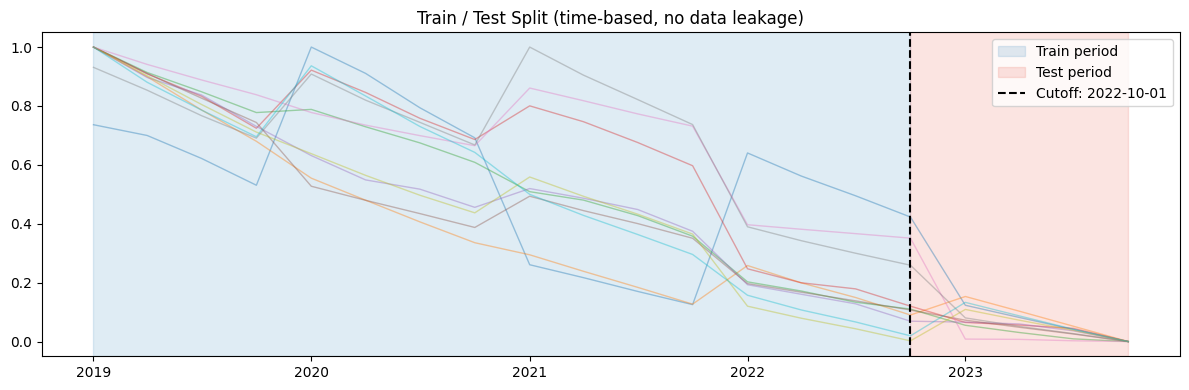

In [10]:
from src.features import time_split, save_features

df_train, df_test = time_split(df_features, test_quarters=4)

print(f"Train: {len(df_train):,} rows | {df_train['period'].min().date()} → {df_train['period'].max().date()}")
print(f"Test:  {len(df_test):,} rows  | {df_test['period'].min().date()} → {df_test['period'].max().date()}")

# Visualise the split
fig, ax = plt.subplots(figsize=(12, 4))
cutoff = df_test['period'].min()
ax.axvspan(panel['period'].min(), cutoff, alpha=0.15, color='#2980b9', label='Train period')
ax.axvspan(cutoff, panel['period'].max(), alpha=0.15, color='#e74c3c', label='Test period')

for sector, grp in panel.groupby('sector'):
    grp = grp.sort_values('period')
    ax.plot(grp['period'], grp['vitality_score'], alpha=0.4, linewidth=1)

ax.axvline(cutoff, color='black', linestyle='--', linewidth=1.5, label=f'Cutoff: {cutoff.date()}')
ax.set_title('Train / Test Split (time-based, no data leakage)')
ax.legend() 
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_train_test_split.png', dpi=120)
plt.show()


In [11]:
# Save the feature dataset as artifact
path = save_features(df_features, feature_dir='../artifacts/processed')
print(f"Features saved to: {path}")


2026-04-16 17:20:38,013 [INFO] Feature dataset saved → ../artifacts/processed/features_latest.csv


Features saved to: ../artifacts/processed/features_latest.csv
